In [2]:
import sys, os
import torch

project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if project_root not in sys.path:
    sys.path.append(project_root)
    
from src.model.unet import UNet

model = UNet(
    in_channels=1,
    out_channels=2,
    n_blocks=4,
    start_filters=32,
    activation="relu",
    normalization="batch",
    conv_mode="same",
    attention=True
)

x = torch.randn(size=(1, 1, 13, 512, 512), dtype=torch.float32)
with torch.no_grad():
    out = model(x)

print(f"Out: {out}")

Out: (tensor([[[[[ 5.8412e-01,  6.3461e-01,  1.5496e+00,  ...,  4.6651e-01,
             4.3158e-01,  8.8455e-01],
           [ 6.7008e-01,  7.9130e-01, -5.0403e-01,  ..., -1.0114e+00,
             5.1962e-01,  1.2084e+00],
           [ 5.2580e-01,  9.1091e-01,  6.8559e-01,  ...,  1.0564e+00,
             4.5501e-01,  1.3441e+00],
           ...,
           [ 7.1797e-01,  4.0056e-01, -4.1440e-01,  ...,  2.0077e+00,
             1.5153e+00,  2.6242e+00],
           [ 4.3310e-01,  9.4833e-01, -7.4908e-02,  ...,  1.8032e+00,
             3.5837e-01,  2.8478e-01],
           [ 4.9001e-01,  8.6005e-01,  4.1507e-01,  ...,  1.0754e+00,
             4.8759e-01,  5.3545e-01]],

          [[ 9.9434e-01,  1.3391e-01,  2.8245e-02,  ...,  3.6731e-01,
             1.5644e+00,  7.4721e-01],
           [ 1.1618e+00, -3.8313e-01,  6.0600e-01,  ...,  1.8647e+00,
             1.2419e-01,  1.0475e+00],
           [ 5.9852e-01,  6.3739e-01, -1.5614e-01,  ..., -9.3679e-01,
            -7.2264e-01,  4.1415e-

In [3]:
from torchinfo import summary

summary = summary(model=model, input_size=(1, 1, 13, 512, 512), device="cpu")
summary

ModuleNotFoundError: No module named 'torchinfo'

In [5]:
import pickle
import matplotlib.pyplot as plt
from pathlib import Path

base_output = Path(project_root + "cloud_models/MihaiB-dev/suppression-loss_threshold-on-gauss-5")
history_path = Path("/home/ami/DL-aneurysm-detection/cloud_models/RusnacAM/AMR_003/history.pickle")

with open(history_path, "rb") as f:
    data = pickle.load(f)
    
print(data)

if isinstance(data, dict):
    for key, val in data.items():
        print(key, ":", len(val))

{'train_loss': [np.float64(0.848679783825691), np.float64(0.7272621467709541), np.float64(0.7342225273068135), np.float64(0.7035011712175149), np.float64(0.6940241605043411), np.float64(0.7107877791501008), np.float64(0.7046006582677364), np.float64(0.6989197163627698), np.float64(0.70708976026911), np.float64(0.6887166864023759), np.float64(0.6864623198142419), np.float64(0.6915541976117171), np.float64(0.6784722555715305), np.float64(0.6794664553151681), np.float64(0.6778416017500254), np.float64(0.6770098217977927), np.float64(0.6942401370750024), np.float64(0.6760166860543765), np.float64(0.675444235595373), np.float64(0.6750311040534422), np.float64(0.667127781189405), np.float64(0.6656869202852249), np.float64(0.662254404849731), np.float64(0.6637755451867213), np.float64(0.6612373851239681), np.float64(0.6604289919711076), np.float64(0.665189190266224), np.float64(0.6640988278847474), np.float64(0.6619455502010309), np.float64(0.6618650873693136), np.float64(0.6604951433837414),

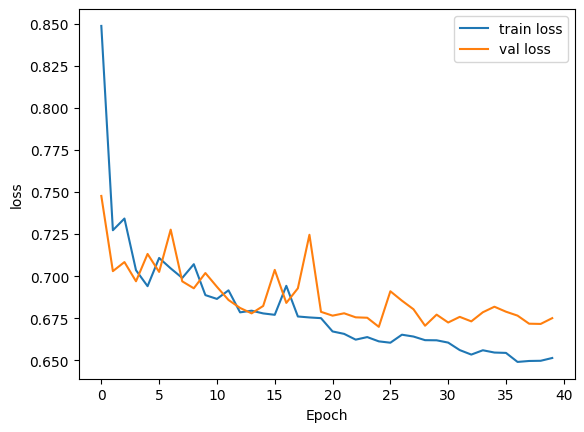

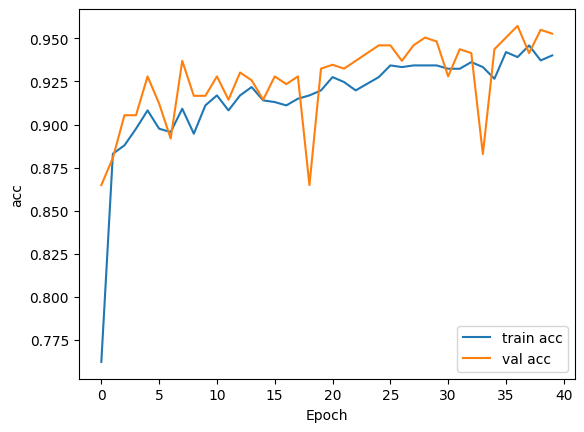

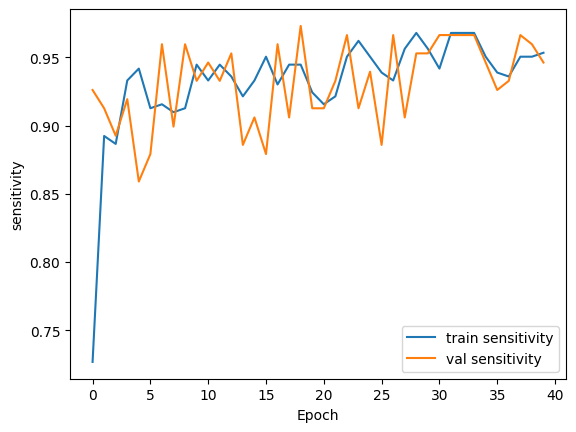

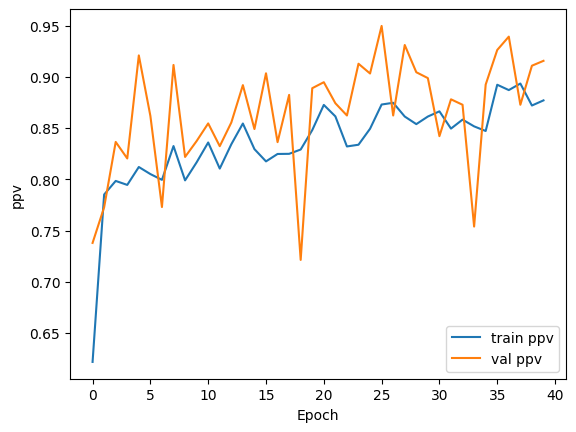

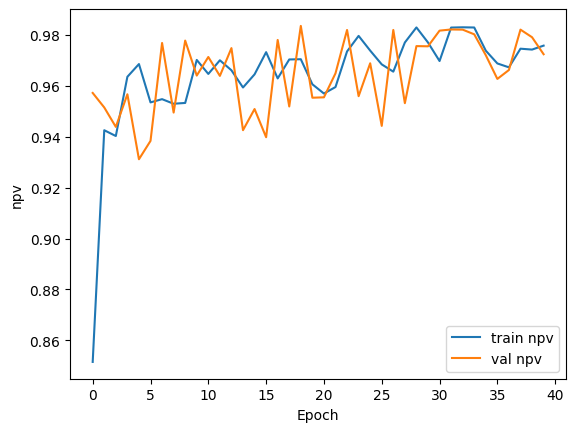

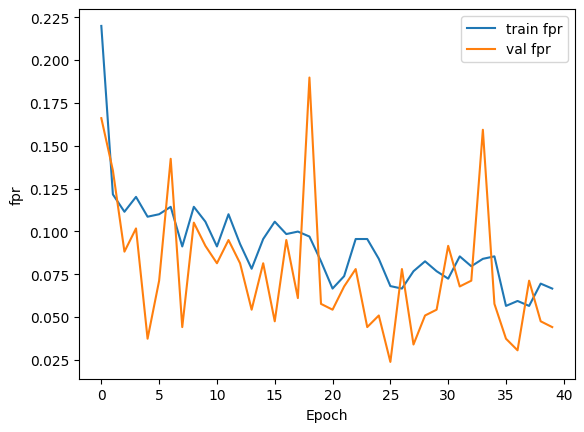

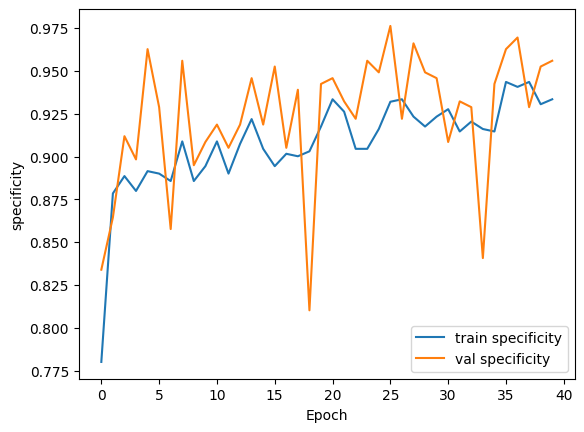

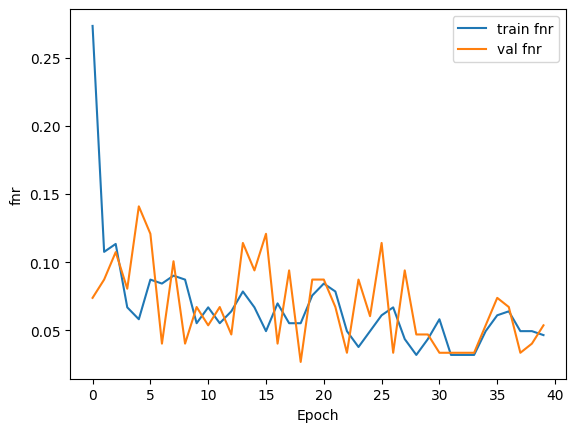

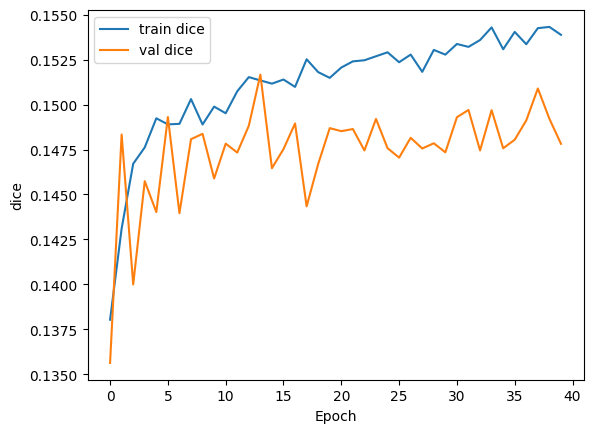

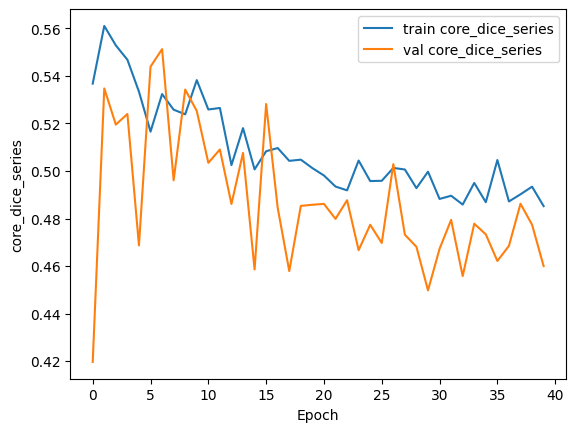

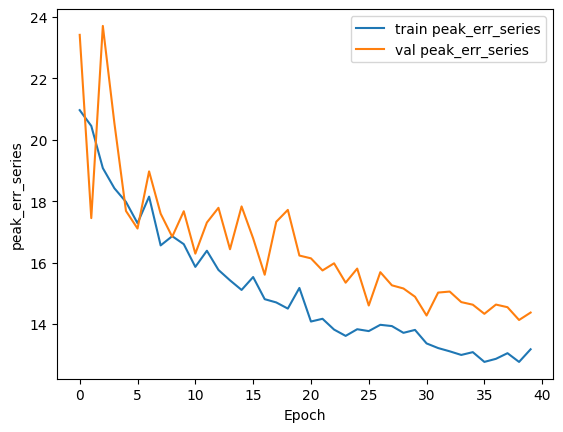

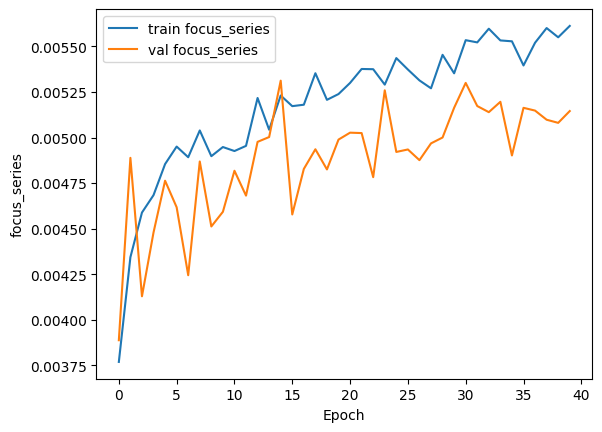

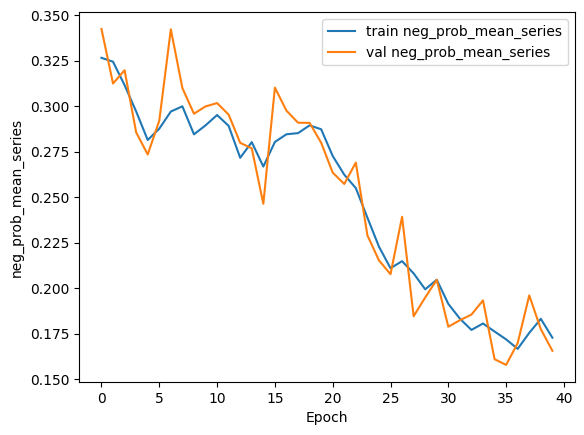

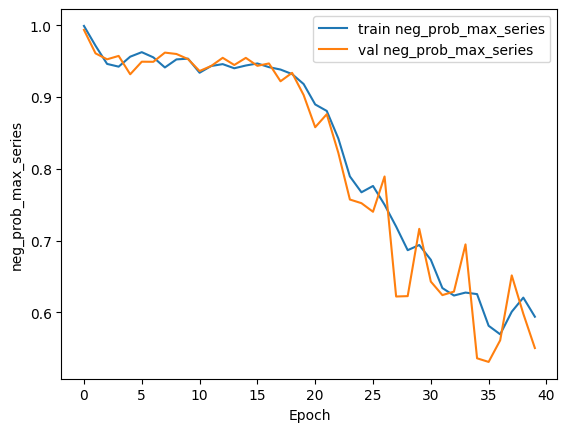

In [6]:
for key in data.keys():
        if key.startswith("train"):
            metric = key[len("train_") :]
            fig = plt.figure()
            plt.plot(data.get(f"train_{metric}", []), label=f"train {metric}")
            plt.plot(data.get(f"val_{metric}", []), label=f"val {metric}")
            plt.xlabel("Epoch")
            plt.ylabel(metric)
            plt.legend()

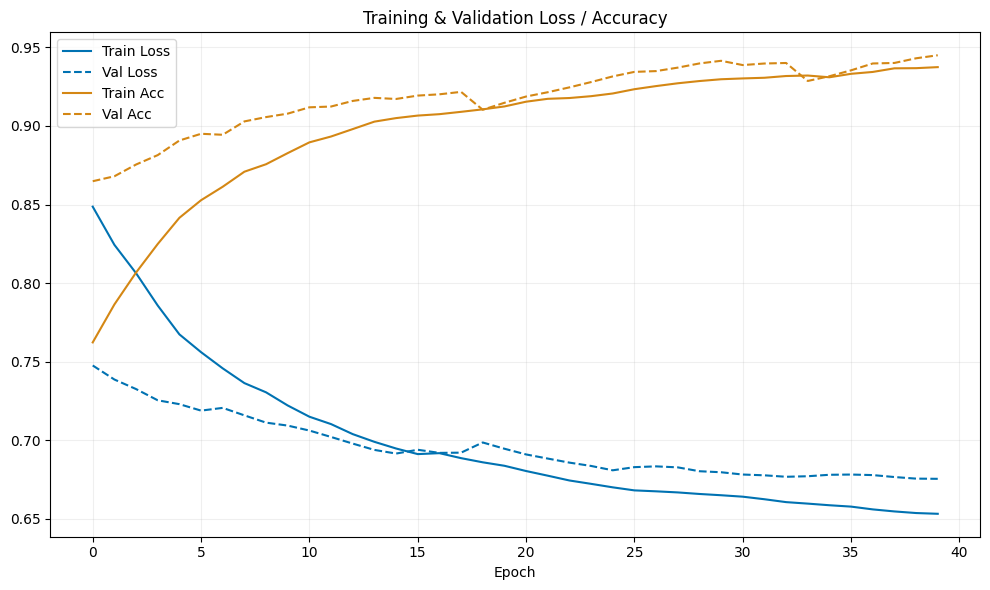

In [10]:
def ema_smooth(values, alpha=0.1):
    if len(values) == 0:
        return values
    smoothed = []
    ema_prev = values[0]
    for v in values:
        ema_prev = alpha * v + (1 - alpha) * ema_prev
        smoothed.append(ema_prev)
    return smoothed

alpha = 0.2
loss_color = "#0072B2"   # blue
acc_color  = "#D48714"   # orange

train_loss = ema_smooth(data.get("train_loss", []), alpha)
val_loss  = ema_smooth(data.get("val_loss", []), alpha)
train_acc  = ema_smooth(data.get("train_acc", []), alpha)
val_acc    = ema_smooth(data.get("val_acc", []), alpha)

plt.figure(figsize=(10, 6))

plt.plot(train_loss, label="Train Loss", color=loss_color, linestyle="-")
plt.plot(val_loss,   label="Val Loss",   color=loss_color, linestyle="--")

plt.plot(train_acc, label="Train Acc", color=acc_color, linestyle="-")
plt.plot(val_acc,   label="Val Acc",   color=acc_color, linestyle="--")

plt.xlabel("Epoch")
plt.title("Training & Validation Loss / Accuracy")
plt.legend()
plt.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()
